# (21) effect of n_iters_inner

project = ```_IterativeVAE```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>

using poisson, (16, 24.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
project_name = '_IterativeVAE'
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Trainer

In [3]:
root = add_home(pjoin('Dropbox/chkpts', project_name))
fit_name = 'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38)'

tr, meta = load_model_lite(pjoin(root, fit_name), device)
meta['checkpoint']

300

100%|███████████████████████████████████| 2/2 [00:52<00:00, 26.47s/it]


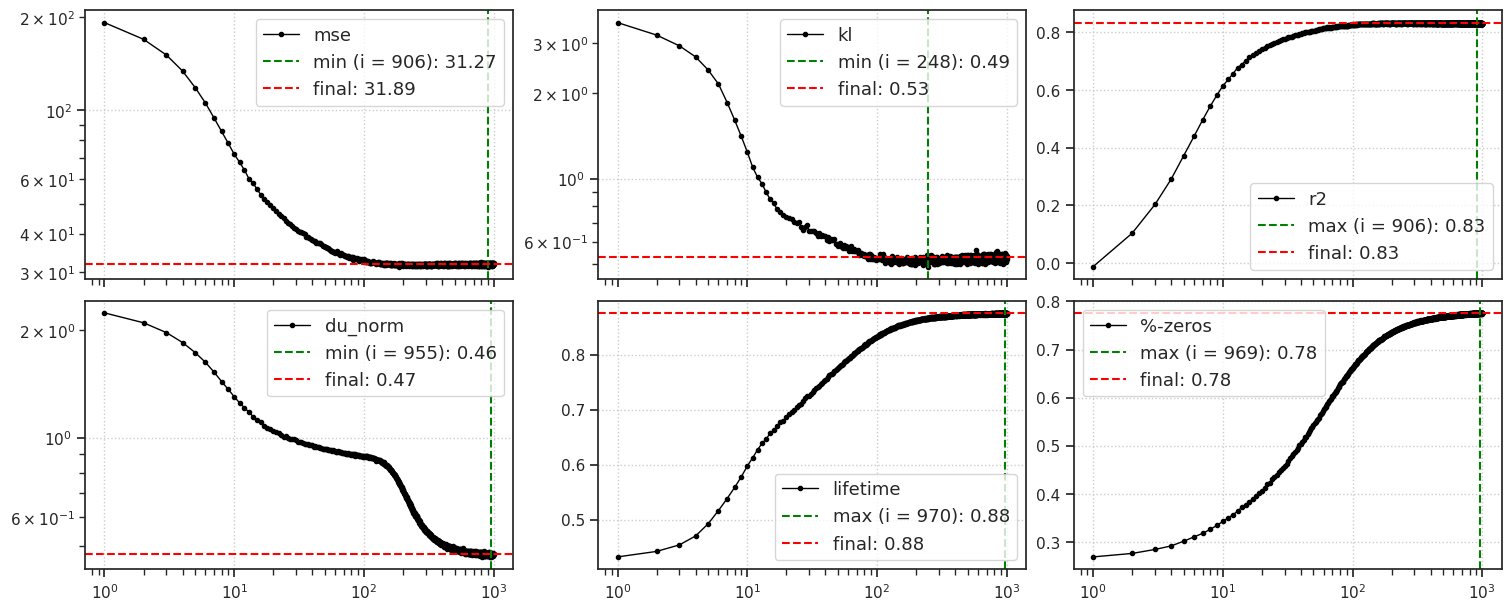

CPU times: user 15.5 s, sys: 2.31 s, total: 17.8 s
Wall time: 56.7 s


In [4]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [5]:
tr.model.cfg.n_iters_inner = 64
tr.model.cfg.beta_inner = 1.0

100%|███████████████████████████████████| 2/2 [02:29<00:00, 74.78s/it]


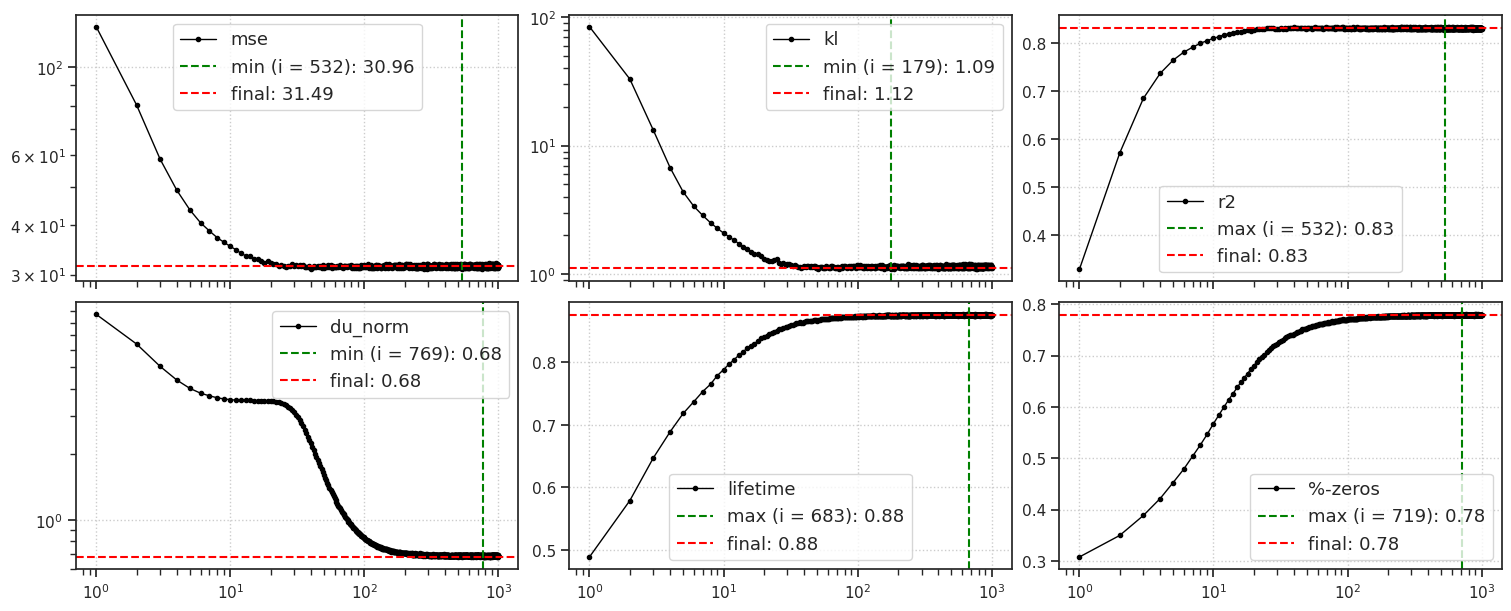

CPU times: user 2min 32s, sys: 929 ms, total: 2min 33s
Wall time: 2min 33s


In [6]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [7]:
tr.model.cfg.n_iters_inner = 64
tr.model.cfg.beta_inner = 1024.0

100%|███████████████████████████████████| 2/2 [02:32<00:00, 76.12s/it]


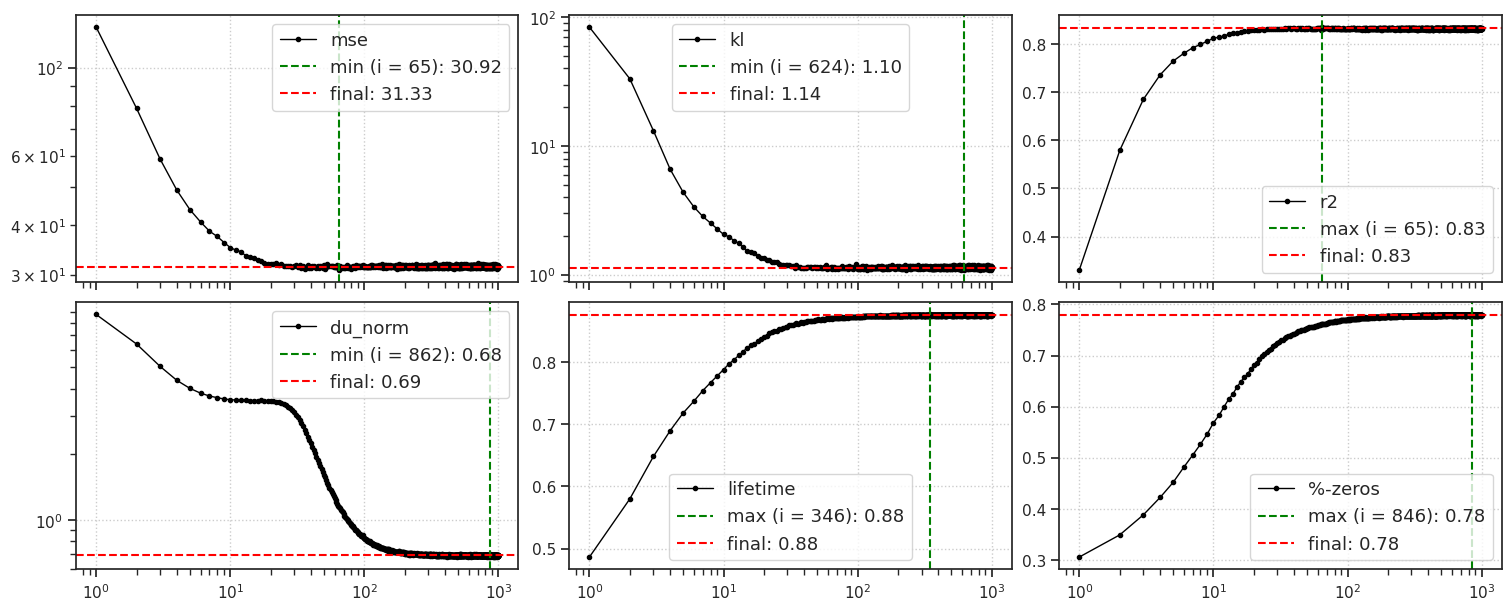

CPU times: user 2min 34s, sys: 821 ms, total: 2min 35s
Wall time: 2min 35s


In [8]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')